# 🐱 CatBoost Advanced Pipeline (Modified from Grandmaster Starter)

**Legal & Acknowledgement:** 
The foundational architecture, CatBoost configuration, and K-Fold training loop in this notebook were adapted from the excellent [CatBoost Starter Notebook] by Kaggle 4x Grandmaster Chris Deotte. 

His original work was released under the **Apache 2.0 Open Source License**. 

### 🛠️ My Custom Modifications:
I have extended Chris's original pipeline by engineering the following custom behavioral features:
1. `is_sleep_deprived`: A binary threshold catching users with dangerously low sleep (< 6 hours).
2. `spam_intensity`: A ratio of notifications per screen-time hour to measure notification overwhelm.
3. Simplified the data loading mechanism for local execution.

In [2]:
from pathlib import Path
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

from catboost import CatBoostClassifier, Pool
import catboost

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

SEED = 42
N_SPLITS = 5
TARGET = 'addicted_label'
ID_COL = 'id'

USE_GPU = False
VERBOSE_EVAL = 100
FAST_DEV_RUN = False

np.random.seed(SEED)

print('✅ Cat carrier loaded!')
print('CatBoost version:', catboost.__version__)
print('Mode:', 'FAST DEV RUN' if FAST_DEV_RUN else 'FULL CV RUN')
print('Task type:', 'GPU' if USE_GPU else 'CPU')


✅ Cat carrier loaded!
CatBoost version: 1.2.10
Mode: FULL CV RUN
Task type: CPU


In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape :', test.shape)
print('Target mean:', f"{train[TARGET].mean():.4f}")

display(train.head())

Train shape: (691369, 14)
Test shape : (296302, 13)
Target mean: 0.7094


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [4]:
raw_features = [c for c in train.columns if c not in [ID_COL, TARGET]]
assert TARGET in train.columns
assert TARGET not in test.columns
assert set(raw_features) == set(c for c in test.columns if c != ID_COL)
assert set(train[TARGET].dropna().unique()).issubset({0, 1})
assert train[ID_COL].is_unique and test[ID_COL].is_unique

summary = pd.DataFrame({
    'dtype': train[raw_features].dtypes.astype(str),
    'unique': train[raw_features].nunique(dropna=True),
    'missing_%': train[raw_features].isna().mean().mul(100),
}).sort_values('missing_%', ascending=False)

display(summary.style.format({'missing_%': '{:.2f}%'}))


,dtype,unique,missing_%
social_media_hours,float64,721,19.38%
gaming_hours,float64,401,18.34%
weekend_screen_time,float64,1437,16.21%
daily_screen_time_hours,float64,1389,13.86%
app_opens_per_day,float64,166,11.67%
notifications_per_day,float64,231,9.78%
stress_level,object,3,7.98%
work_study_hours,float64,600,7.45%
sleep_hours,float64,451,6.43%
academic_work_impact,object,2,6.40%


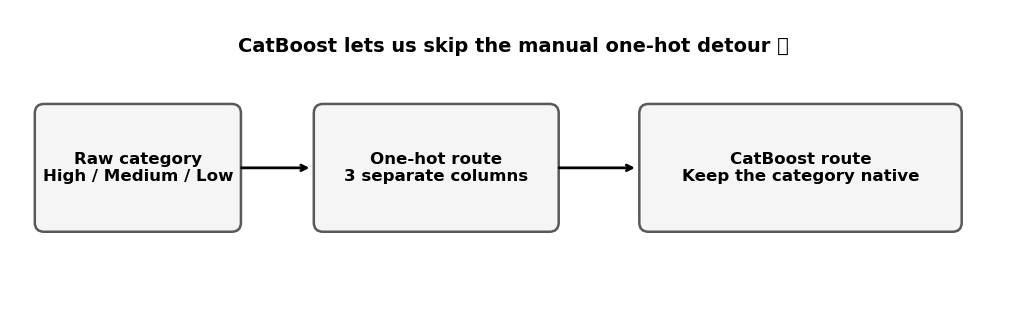

In [5]:
# Tiny visual: three ways to think about one categorical column.
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13)
ax.set_ylim(0, 4)
ax.axis('off')

boxes = [
    (0.4, 1.2, 2.5, 1.5, 'Raw category\nHigh / Medium / Low'),
    (4.0, 1.2, 3.0, 1.5, 'One-hot route\n3 separate columns'),
    (8.2, 1.2, 4.0, 1.5, 'CatBoost route\nKeep the category native'),
]
for x, y, w, h, label in boxes:
    patch = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.08,rounding_size=0.12',
                           linewidth=1.8, edgecolor='0.35', facecolor='0.96')
    ax.add_patch(patch)
    ax.text(x+w/2, y+h/2, label, ha='center', va='center', fontsize=12, fontweight='bold')

ax.annotate('', xy=(3.9, 1.95), xytext=(2.95, 1.95), arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(8.1, 1.95), xytext=(7.05, 1.95), arrowprops=dict(arrowstyle='->', lw=2))
ax.text(6.5, 3.45, 'CatBoost lets us skip the manual one-hot detour 🐾', ha='center', fontsize=14, fontweight='bold')
plt.show()


In [6]:
CATEGORICAL_COLS = ['gender', 'stress_level', 'academic_work_impact']


def safe_divide(num: pd.Series, den: pd.Series) -> pd.Series:
    return num / den.replace(0, np.nan)


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # How much information is missing in this row?
    base_predictors = [c for c in out.columns if c != ID_COL]
    out['missing_count'] = out[base_predictors].isna().sum(axis=1).astype('float32')

    # Screen-time composition.
    component_cols = ['social_media_hours', 'gaming_hours', 'work_study_hours']
    out['screen_component_total'] = out[component_cols].sum(axis=1, min_count=len(component_cols))
    out['time_accounting_residual'] = (
        out['daily_screen_time_hours']
        - out['social_media_hours']
        - out['gaming_hours']
        - out['work_study_hours']
    )
    out['weekend_lift'] = out['weekend_screen_time'] - out['daily_screen_time_hours']
    out['weekend_ratio'] = safe_divide(out['weekend_screen_time'], out['daily_screen_time_hours'])

    # Shares of total daily screen time.
    out['social_share_of_daily'] = safe_divide(out['social_media_hours'], out['daily_screen_time_hours'])
    out['gaming_share_of_daily'] = safe_divide(out['gaming_hours'], out['daily_screen_time_hours'])
    out['work_study_share_of_daily'] = safe_divide(out['work_study_hours'], out['daily_screen_time_hours'])

    # Sleep / screen balance.
    out['sleep_minus_screen'] = out['sleep_hours'] - out['daily_screen_time_hours']
    out['screen_to_sleep_ratio'] = safe_divide(out['daily_screen_time_hours'], out['sleep_hours'])

    # Engagement intensity.
    out['opens_per_screen_hour'] = safe_divide(out['app_opens_per_day'], out['daily_screen_time_hours'])
    out['notifications_per_screen_hour'] = safe_divide(out['notifications_per_day'], out['daily_screen_time_hours'])
    out['notifications_per_open'] = safe_divide(out['notifications_per_day'], out['app_opens_per_day'])
    out['engagement_events'] = out['notifications_per_day'] + out['app_opens_per_day']

    out['is_sleep_deprived'] = (out['sleep_hours'] < 6.0).astype(int)
    out['spam_intensity'] = safe_divide(out['notifications_per_day'], out['daily_screen_time_hours'])

    out = out.replace([np.inf, -np.inf], np.nan)

    # CatBoost categorical columns cannot contain numeric NaN values.
    # Give missing categories a real string label instead.
    for c in CATEGORICAL_COLS:
        if c in out.columns:
            out[c] = out[c].fillna('(missing)').astype(str)

    return out


train_fe = engineer_features(train.drop(columns=[TARGET]))
test_fe = engineer_features(test.copy())

train_ids = train[ID_COL].copy()
test_ids = test[ID_COL].copy()
y = train[TARGET].astype(np.int8).copy()

X = train_fe.drop(columns=[ID_COL]).reset_index(drop=True)
X_test = test_fe.drop(columns=[ID_COL]).reset_index(drop=True)

assert X.columns.equals(X_test.columns)
assert len(X) == len(y)

cat_features = [c for c in CATEGORICAL_COLS if c in X.columns]
num_features = [c for c in X.columns if c not in cat_features]

print('Raw predictors       :', len(raw_features))
print('Engineered predictors:', X.shape[1])
print('Numeric model columns:', len(num_features))
print('Native categoricals  :', cat_features)
print('No one-hot encoding! 😺')


Raw predictors       : 12
Engineered predictors: 28
Numeric model columns: 25
Native categoricals  : ['gender', 'stress_level', 'academic_work_impact']
No one-hot encoding! 😺


In [7]:
CAT_PARAMS = dict(
    iterations=3000 if not FAST_DEV_RUN else 160,
    learning_rate=0.035 if not FAST_DEV_RUN else 0.08,
    depth=7,
    l2_leaf_reg=5.0,
    random_strength=0.5,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=SEED,
    allow_writing_files=False,
    thread_count=-1,
    task_type='GPU' if USE_GPU else 'CPU',
)

EARLY_STOPPING_ROUNDS = 150 if not FAST_DEV_RUN else 35

pd.Series({**CAT_PARAMS, 'early_stopping_rounds': EARLY_STOPPING_ROUNDS}, name='value').to_frame()


,value
iterations,3000
learning_rate,0.035
depth,7
l2_leaf_reg,5.0
random_strength,0.5
loss_function,Logloss
eval_metric,AUC
random_seed,42
allow_writing_files,False
thread_count,-1


In [8]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_pred = np.zeros(len(train), dtype=np.float64)
test_pred = np.zeros(len(test), dtype=np.float64)
fold_assignment = np.full(len(train), -1, dtype=np.int8)

fold_metrics = []
importance_frames = []
history_frames = []
models = []

cv_start = time.time()

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print('\n' + '=' * 78)
    print(f'🐱 FOLD {fold}/{N_SPLITS} — release the boosted cats!')
    print('=' * 78)

    X_tr, X_va = X.iloc[train_idx], X.iloc[valid_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[valid_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_va, y_va, cat_features=cat_features)
    test_pool = Pool(X_test, cat_features=cat_features)

    model = CatBoostClassifier(**CAT_PARAMS)
    fold_start = time.time()

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        verbose=VERBOSE_EVAL,
    )

    va_pred = model.predict_proba(valid_pool)[:, 1]
    fold_auc = roc_auc_score(y_va, va_pred)

    oof_pred[valid_idx] = va_pred
    fold_assignment[valid_idx] = fold
    test_pred += model.predict_proba(test_pool)[:, 1] / N_SPLITS

    best_iteration = model.get_best_iteration()
    best_scores = model.get_best_score()
    reported_auc = best_scores.get('validation', {}).get('AUC', np.nan)
    elapsed = time.time() - fold_start

    fold_metrics.append({
        'fold': fold,
        'auc': fold_auc,
        'best_iteration': None if best_iteration is None or best_iteration < 0 else int(best_iteration) + 1,
        'best_score_reported_by_catboost': reported_auc,
        'seconds': elapsed,
    })

    # CatBoost's default FeatureImportance for classification is PredictionValuesChange.
    imp = model.get_feature_importance(type='FeatureImportance')
    fold_imp = pd.DataFrame({
        'feature': X.columns,
        'importance_pct': imp,
        'fold': fold,
    })
    importance_frames.append(fold_imp)

    # Keep validation AUC history so we can plot how boosting learned.
    evals = model.get_evals_result()
    val_auc_history = evals.get('validation', {}).get('AUC', [])
    if len(val_auc_history):
        history_frames.append(pd.DataFrame({
            'fold': fold,
            'iteration': np.arange(1, len(val_auc_history) + 1),
            'val_auc': val_auc_history,
        }))

    models.append(model)

    print(f'\n🎯 Fold {fold} AUC: {fold_auc:.6f}')
    if best_iteration is not None and best_iteration >= 0:
        print(f'🌳 Best boosting round: {best_iteration + 1:,}')
    print(f'⏱️  Fold time: {elapsed/60:.2f} min')

    # Running scoreboard after every fold.
    display(pd.DataFrame(fold_metrics).style.format({'auc': '{:.6f}', 'seconds': '{:.1f}'}))

cv_minutes = (time.time() - cv_start) / 60
print(f'\n✅ Five-fold CatBoost training finished in {cv_minutes:.2f} minutes.')



🐱 FOLD 1/5 — release the boosted cats!
0:	test: 0.9103168	best: 0.9103168 (0)	total: 263ms	remaining: 13m 9s
100:	test: 0.9372978	best: 0.9372978 (100)	total: 18.4s	remaining: 8m 48s
200:	test: 0.9426552	best: 0.9426552 (200)	total: 36.3s	remaining: 8m 26s
300:	test: 0.9460348	best: 0.9460348 (300)	total: 54.3s	remaining: 8m 6s
400:	test: 0.9488740	best: 0.9488740 (400)	total: 1m 11s	remaining: 7m 44s
500:	test: 0.9510772	best: 0.9510772 (500)	total: 1m 29s	remaining: 7m 24s
600:	test: 0.9528565	best: 0.9528565 (600)	total: 1m 46s	remaining: 7m 5s
700:	test: 0.9543227	best: 0.9543227 (700)	total: 2m 4s	remaining: 6m 46s
800:	test: 0.9553591	best: 0.9553591 (800)	total: 2m 21s	remaining: 6m 28s
900:	test: 0.9562829	best: 0.9562829 (900)	total: 2m 40s	remaining: 6m 13s
1000:	test: 0.9570149	best: 0.9570149 (1000)	total: 2m 59s	remaining: 5m 58s
1100:	test: 0.9576787	best: 0.9576787 (1100)	total: 3m 18s	remaining: 5m 43s
1200:	test: 0.9582197	best: 0.9582197 (1200)	total: 3m 37s	remainin

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962230,3000,0.962230,546.4



🐱 FOLD 2/5 — release the boosted cats!
0:	test: 0.9110608	best: 0.9110608 (0)	total: 168ms	remaining: 8m 23s
100:	test: 0.9378647	best: 0.9378647 (100)	total: 18.1s	remaining: 8m 39s
200:	test: 0.9431893	best: 0.9431893 (200)	total: 35.6s	remaining: 8m 15s
300:	test: 0.9467062	best: 0.9467062 (300)	total: 53.1s	remaining: 7m 56s
400:	test: 0.9497568	best: 0.9497568 (400)	total: 1m 10s	remaining: 7m 37s
500:	test: 0.9519640	best: 0.9519640 (500)	total: 1m 28s	remaining: 7m 19s
600:	test: 0.9536612	best: 0.9536612 (600)	total: 1m 45s	remaining: 7m
700:	test: 0.9549586	best: 0.9549586 (700)	total: 2m 2s	remaining: 6m 42s
800:	test: 0.9560763	best: 0.9560763 (800)	total: 2m 19s	remaining: 6m 23s
900:	test: 0.9567804	best: 0.9567804 (900)	total: 2m 36s	remaining: 6m 3s
1000:	test: 0.9574193	best: 0.9574193 (1000)	total: 2m 52s	remaining: 5m 44s
1100:	test: 0.9580713	best: 0.9580713 (1100)	total: 3m 9s	remaining: 5m 26s
1200:	test: 0.9586161	best: 0.9586161 (1200)	total: 3m 25s	remaining: 5

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962230,3000,0.962230,546.4
1,2,0.962747,2999,0.962747,533.6



🐱 FOLD 3/5 — release the boosted cats!
0:	test: 0.9113459	best: 0.9113459 (0)	total: 182ms	remaining: 9m 4s
100:	test: 0.9385655	best: 0.9385655 (100)	total: 17.7s	remaining: 8m 28s
200:	test: 0.9439996	best: 0.9439996 (200)	total: 35.1s	remaining: 8m 8s
300:	test: 0.9472675	best: 0.9472675 (300)	total: 52.4s	remaining: 7m 50s
400:	test: 0.9501119	best: 0.9501119 (400)	total: 1m 9s	remaining: 7m 31s
500:	test: 0.9523230	best: 0.9523230 (500)	total: 1m 26s	remaining: 7m 13s
600:	test: 0.9537734	best: 0.9537734 (600)	total: 1m 44s	remaining: 6m 55s
700:	test: 0.9552339	best: 0.9552339 (700)	total: 2m 3s	remaining: 6m 46s
800:	test: 0.9562355	best: 0.9562355 (800)	total: 2m 26s	remaining: 6m 42s
900:	test: 0.9571163	best: 0.9571163 (900)	total: 2m 49s	remaining: 6m 34s
1000:	test: 0.9578582	best: 0.9578582 (1000)	total: 3m 11s	remaining: 6m 22s
1100:	test: 0.9585004	best: 0.9585004 (1100)	total: 3m 33s	remaining: 6m 7s
1200:	test: 0.9590330	best: 0.9590330 (1200)	total: 3m 55s	remaining:

...


🐱 FOLD 4/5 — release the boosted cats!
0:	test: 0.9121013	best: 0.9121013 (0)	total: 177ms	remaining: 8m 51s
100:	test: 0.9390210	best: 0.9390210 (100)	total: 18.4s	remaining: 8m 49s
200:	test: 0.9446077	best: 0.9446077 (200)	total: 36.6s	remaining: 8m 29s
300:	test: 0.9481554	best: 0.9481554 (300)	total: 54.6s	remaining: 8m 9s
400:	test: 0.9510196	best: 0.9510196 (400)	total: 1m 12s	remaining: 7m 50s
500:	test: 0.9530297	best: 0.9530297 (500)	total: 1m 30s	remaining: 7m 31s
600:	test: 0.9546922	best: 0.9546935 (599)	total: 1m 48s	remaining: 7m 14s
700:	test: 0.9560837	best: 0.9560837 (700)	total: 2m 7s	remaining: 6m 56s
800:	test: 0.9571838	best: 0.9571838 (800)	total: 2m 25s	remaining: 6m 38s
900:	test: 0.9581591	best: 0.9581591 (900)	total: 2m 43s	remaining: 6m 21s
1000:	test: 0.9589194	best: 0.9589194 (1000)	total: 3m 2s	remaining: 6m 3s
1100:	test: 0.9595165	best: 0.9595165 (1100)	total: 3m 22s	remaining: 5m 49s
1200:	test: 0.9600567	best: 0.9600567 (1200)	total: 3m 46s	remaining

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962230,3000,0.962230,546.4
1,2,0.962747,2999,0.962747,533.6
2,3,0.962947,3000,0.962947,608.9
3,4,0.963837,3000,0.963837,654.7



🐱 FOLD 5/5 — release the boosted cats!
0:	test: 0.9140834	best: 0.9140834 (0)	total: 265ms	remaining: 13m 15s
100:	test: 0.9382219	best: 0.9382219 (100)	total: 23.8s	remaining: 11m 24s
200:	test: 0.9435914	best: 0.9435914 (200)	total: 47.2s	remaining: 10m 57s
300:	test: 0.9471465	best: 0.9471465 (300)	total: 1m 10s	remaining: 10m 32s
400:	test: 0.9498504	best: 0.9498504 (400)	total: 1m 33s	remaining: 10m 7s
500:	test: 0.9520743	best: 0.9520743 (500)	total: 1m 56s	remaining: 9m 43s
600:	test: 0.9537044	best: 0.9537044 (600)	total: 2m 20s	remaining: 9m 20s
700:	test: 0.9548871	best: 0.9548871 (700)	total: 2m 44s	remaining: 8m 57s
800:	test: 0.9561043	best: 0.9561043 (800)	total: 3m 8s	remaining: 8m 37s
900:	test: 0.9569747	best: 0.9569747 (900)	total: 3m 32s	remaining: 8m 14s
1000:	test: 0.9577430	best: 0.9577430 (1000)	total: 3m 55s	remaining: 7m 50s
1100:	test: 0.9583908	best: 0.9583908 (1100)	total: 4m 19s	remaining: 7m 26s
1200:	test: 0.9589290	best: 0.9589290 (1200)	total: 4m 42s	r

,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962230,3000,0.962230,546.4
1,2,0.962747,2999,0.962747,533.6
2,3,0.962947,3000,0.962947,608.9
3,4,0.963837,3000,0.963837,654.7
4,5,0.962840,2996,0.962840,732.1



✅ Five-fold CatBoost training finished in 51.34 minutes.


In [9]:
fold_metrics_df = pd.DataFrame(fold_metrics)
overall_oof_auc = roc_auc_score(y, oof_pred)

print('🏆 OVERALL OOF AUC:', f'{overall_oof_auc:.6f}')
print('📈 Mean fold AUC    :', f"{fold_metrics_df['auc'].mean():.6f}")
print('📉 Fold AUC std     :', f"{fold_metrics_df['auc'].std():.6f}")

display(fold_metrics_df.style.format({
    'auc': '{:.6f}',
    'best_score_reported_by_catboost': lambda x: '' if pd.isna(x) else f'{float(x):.6f}',
    'seconds': '{:.1f}',
}))


🏆 OVERALL OOF AUC: 0.962918
📈 Mean fold AUC    : 0.962920
📉 Fold AUC std     : 0.000582


,fold,auc,best_iteration,best_score_reported_by_catboost,seconds
0,1,0.962230,3000,0.962230,546.4
1,2,0.962747,2999,0.962747,533.6
2,3,0.962947,3000,0.962947,608.9
3,4,0.963837,3000,0.963837,654.7
4,5,0.962840,2996,0.962840,732.1


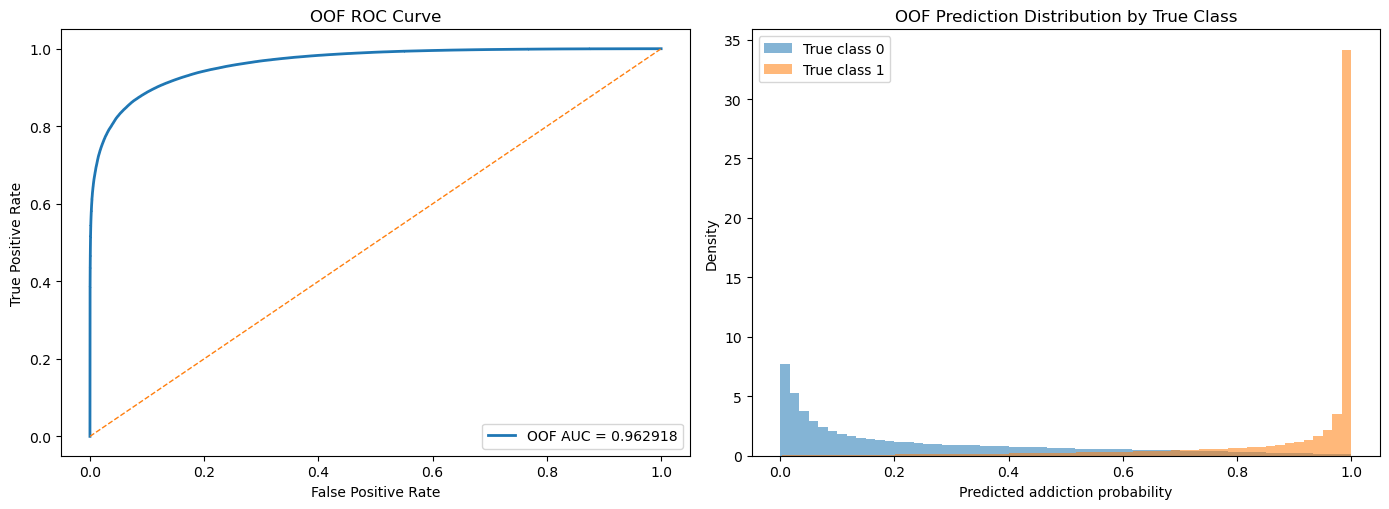

In [10]:
fpr, tpr, _ = roc_curve(y, oof_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].plot(fpr, tpr, linewidth=2, label=f'OOF AUC = {overall_oof_auc:.6f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('OOF ROC Curve')
axes[0].legend()

axes[1].hist(oof_pred[y.values == 0], bins=60, alpha=0.55, density=True, label='True class 0')
axes[1].hist(oof_pred[y.values == 1], bins=60, alpha=0.55, density=True, label='True class 1')
axes[1].set_xlabel('Predicted addiction probability')
axes[1].set_ylabel('Density')
axes[1].set_title('OOF Prediction Distribution by True Class')
axes[1].legend()

plt.tight_layout()
plt.show()


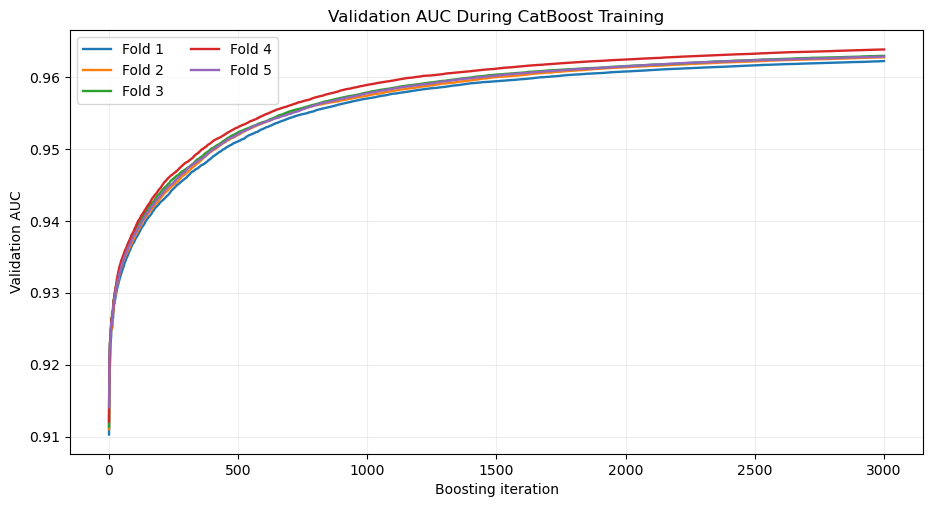

In [11]:
history_df = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()

if not history_df.empty:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for fold, g in history_df.groupby('fold'):
        ax.plot(g['iteration'], g['val_auc'], linewidth=1.7, label=f'Fold {fold}')
    ax.set_xlabel('Boosting iteration')
    ax.set_ylabel('Validation AUC')
    ax.set_title('Validation AUC During CatBoost Training')
    ax.legend(ncol=2)
    ax.grid(alpha=0.2)
    plt.show()
else:
    print('No validation history was returned by this CatBoost build.')


In [12]:
importance_long = pd.concat(importance_frames, ignore_index=True)

# CatBoost normally returns percentages summing to ~100, but normalize explicitly
# so the saved artifact has a clear and stable interpretation.
importance_long['importance_pct'] = importance_long.groupby('fold')['importance_pct'].transform(
    lambda s: 100 * s / s.sum() if s.sum() > 0 else 0.0
)

feature_importance = (
    importance_long
    .groupby('feature', as_index=False)
    .agg(
        mean_importance_pct=('importance_pct', 'mean'),
        importance_pct_std=('importance_pct', 'std'),
    )
    .sort_values('mean_importance_pct', ascending=False)
    .reset_index(drop=True)
)

display(feature_importance.head(25).style.format({
    'mean_importance_pct': '{:.2f}%',
    'importance_pct_std': '{:.2f}%',
}))


,feature,mean_importance_pct,importance_pct_std
0,weekend_screen_time,22.40%,0.42%
1,daily_screen_time_hours,20.61%,0.62%
2,notifications_per_day,12.71%,0.33%
3,app_opens_per_day,11.24%,0.21%
4,social_media_hours,10.70%,0.21%
5,social_share_of_daily,5.36%,0.15%
6,work_study_share_of_daily,3.26%,0.07%
7,gaming_share_of_daily,2.55%,0.07%
8,time_accounting_residual,1.92%,0.05%
9,work_study_hours,1.78%,0.11%


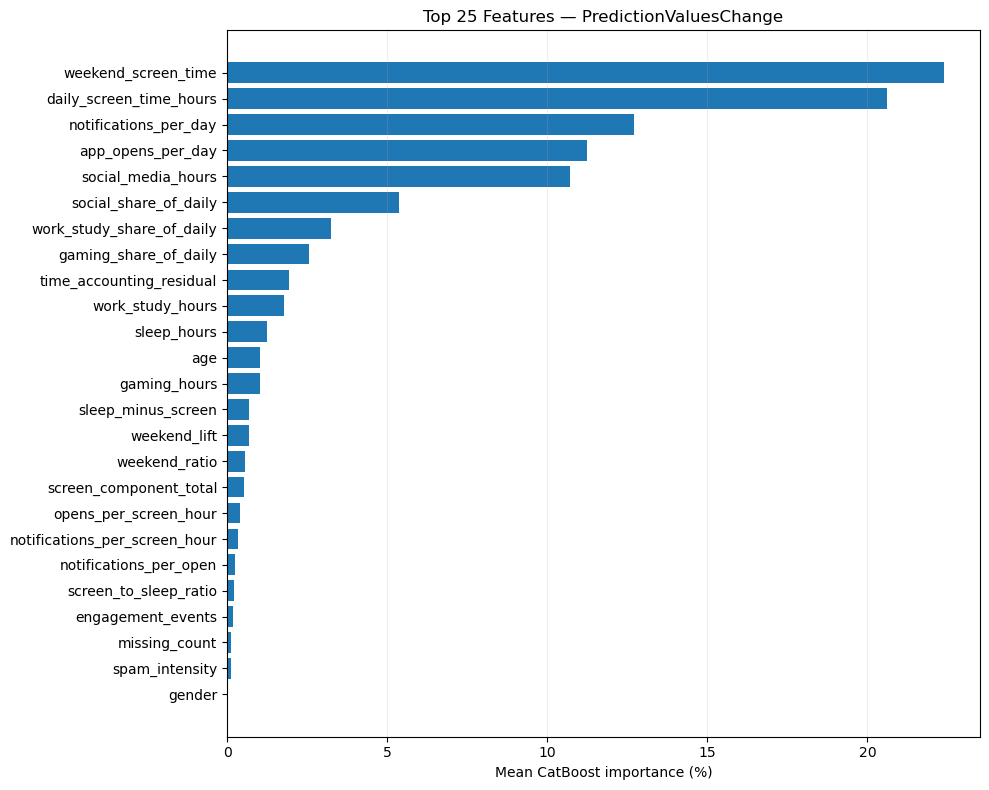

In [13]:
top_n = 25
plot_imp = feature_importance.head(top_n).sort_values('mean_importance_pct')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_imp['feature'], plot_imp['mean_importance_pct'])
ax.set_xlabel('Mean CatBoost importance (%)')
ax.set_title(f'Top {top_n} Features — PredictionValuesChange')
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()


In [14]:
oof_df = pd.DataFrame({
    ID_COL: train_ids,
    TARGET: y,
    'fold': fold_assignment,
    'oof_pred': oof_pred,
})

assert (oof_df['fold'] > 0).all()
assert oof_df['oof_pred'].between(0, 1).all()
assert oof_df['oof_pred'].notna().all()

oof_df.to_csv('oof_predictions.csv', index=False)
fold_metrics_df.to_csv('fold_metrics.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print('✅ Saved oof_predictions.csv')
print('✅ Saved fold_metrics.csv')
print('✅ Saved feature_importance.csv')
display(oof_df.head())


✅ Saved oof_predictions.csv
✅ Saved fold_metrics.csv
✅ Saved feature_importance.csv


,id,addicted_label,fold,oof_pred
0,0,1,4,0.762896
1,1,0,4,0.038975
2,2,0,4,0.399622
3,3,1,5,0.334828
4,4,1,3,0.999772


In [ ]:
submission = pd.DataFrame({ID_COL: test_ids, TARGET: test_pred})
assert submission[TARGET].between(0, 1).all()
assert submission[TARGET].notna().all()

submission.to_csv('submission.csv', index=False)

print('🚀 Saved submission.csv')
print('Prediction mean:', f"{submission[TARGET].mean():.5f}")
print('Prediction min :', f"{submission[TARGET].min():.5f}")
print('Prediction max :', f"{submission[TARGET].max():.5f}")
display(submission.head(10))


🚀 Saved submission.csv
Prediction mean: 0.70939
Prediction min : 0.00021
Prediction max : 1.00000


,id,addicted_label
0,691369,0.999355
1,691370,0.942895
2,691371,0.958931
3,691372,0.983495
4,691373,0.997664
5,691374,0.901039
6,691375,0.902625
7,691376,0.596734
8,691377,0.978066
9,691378,0.288180
